In [9]:
#Simply plot the neuron's response to the same step current given different f parameters


# local imports
import aqua
from aqua.batchAQUA_general import batchAQUA
from aqua.AQUA_general import AQUA
from aqua.stimulus import *
from aqua.plotting_functions import *
from aqua.utils import *

# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fft import fft, ifft, fftfreq


RS = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 0., 'tau': 2.}

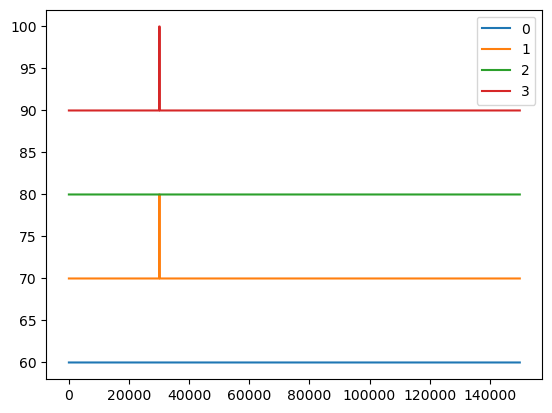

     name    C    k  v_r  v_t  v_peak     a  b   c    d    e    f  tau
0  RS_ref  100  0.7  -60  -40      35  0.03 -2 -50  100  0.2  200  2.0
1  RS_ref  100  0.7  -60  -40      35  0.03 -2 -50  100  0.2  200  2.0
2  RS_ref  100  0.7  -60  -40      35  0.03 -2 -50  100  0.2  400  2.0
3  RS_ref  100  0.7  -60  -40      35  0.03 -2 -50  100  0.2  400  2.0


100%|██████████| 149999/149999 [00:20<00:00, 7435.57it/s]


In [10]:
# test for chaos!
# Take the exact same batch, re-initialise, re-run the simulation 2x (with and without perturbation)
# estimate the distance of the 2 trajectories through time (do they diverge exponentially?)
# 

# ONly consider 2 neuron models... 1 below chaos, 1 in chaos...

f_vals = np.array([200, 400])
I_HEIGHT = 60

T = 15000
dt = 0.1
N_iter = int(T/dt)

N_neurons = 2*len(f_vals)

I_inj = I_HEIGHT * np.ones((N_neurons, N_iter))
perturb_time = 3000 # ms
perturb_idx = int(perturb_time /dt)
perturb_duration = 20 # ms
perturb_steps = int(perturb_duration / dt)
perturb_height = 10
I_inj[1:4:2, perturb_idx:perturb_idx + perturb_steps] += perturb_height          # add a perturbation to 2nd and 4th rows...


for i in range(I_inj.shape[0]):
    plt.plot(I_inj[i, :] + 10*i, label = f'{i}')

plt.legend()
plt.show()

params = []

for n, f in enumerate(f_vals):
    temp = RS.copy()
    temp['f'] = f
    params.append(temp)     # appended twice
    params.append(temp)

df = pd.DataFrame(params)
print(df.head())

x_start = np.full((N_neurons, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(N_neurons)

batch = batchAQUA(params)
batch.Initialise(x_start, t_start)

X, t, spikes = batch.update_batch(dt, N_iter, I_inj)



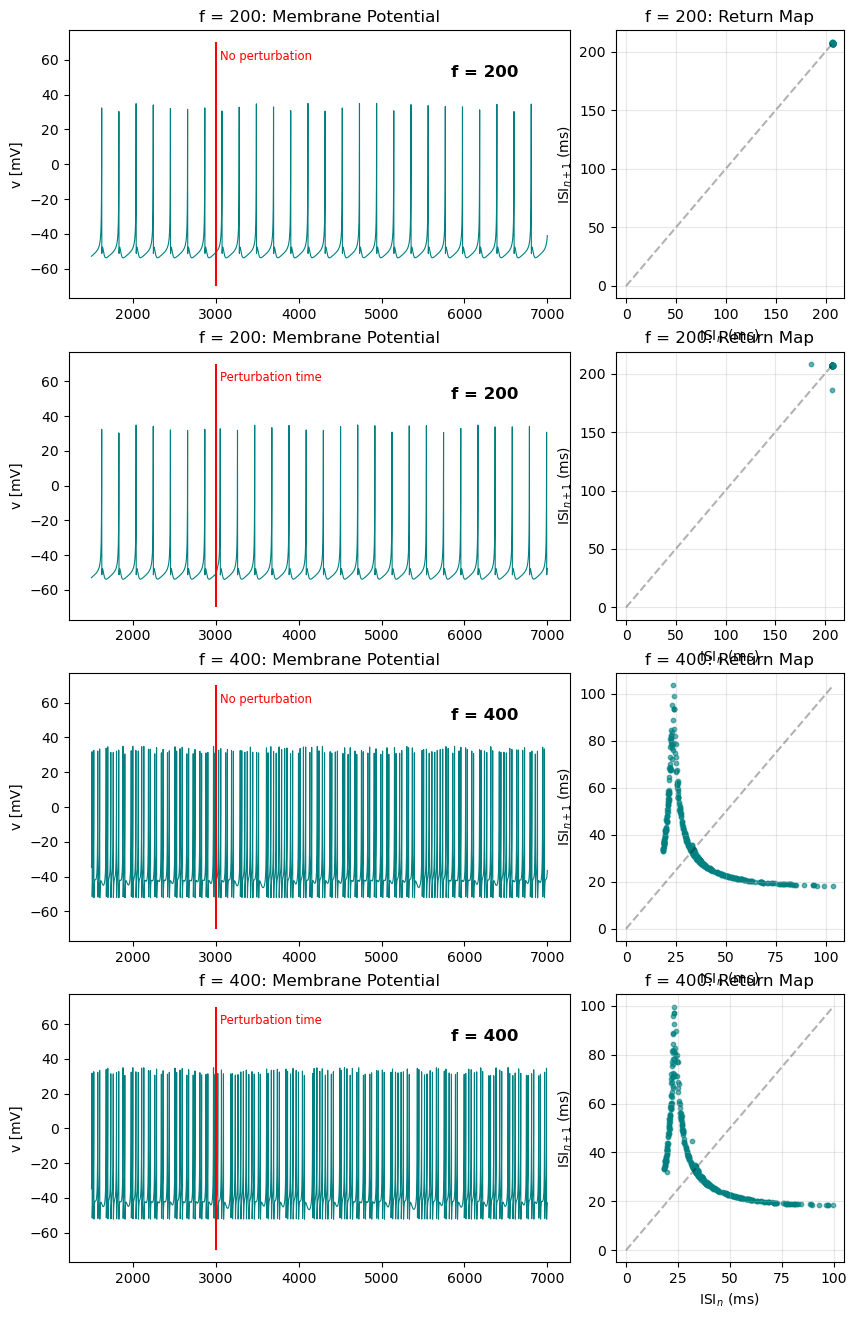

In [11]:
fig = plt.figure(figsize=(10, 4 * N_neurons))
gs = gridspec.GridSpec(N_neurons, 3, figure=fig)
split = np.arange(15000, 70000, 1)     # 2000-5000 ms
for n, f in enumerate(df['f']):
    # 1. Membrane Potential Axis (Spans columns 0 and 1)
    ax_vm = fig.add_subplot(gs[n, 0:2])
    ax_vm.plot(t[split], X[n, 0, split], color='teal', lw=0.8)
    ax_vm.set_title(f"f = {f}: Membrane Potential")
    ax_vm.text(dt*5./6*split[-1], 50, f'f = {f}', fontsize = 'large', fontweight = 'bold')
    if n % 2 == 0:
        ax_vm.text(perturb_time+50, 60, 'No perturbation', color = 'red', fontsize = 'small')
    else:
        ax_vm.text(perturb_time+50, 60, 'Perturbation time', color = 'red', fontsize = 'small')
    ax_vm.vlines(x = perturb_time, ymin = -70, ymax = 70, color = 'red')
    ax_vm.set_ylabel("v [mV]")
    
    # 2. Return Map Axis (Spans column 2)
    ax_map = fig.add_subplot(gs[n, 2])
    
    # Use the function we built previously!
    plot_first_return_map(
        spikes[n], 
        burn_in=500, 
        ax=ax_map, 
        c='teal', 
        s=10
    )
    ax_map.set_title(f"f = {f}: Return Map")

plt.savefig('RS_chaos//RS_w_perturbations.png')
plt.show()

30000


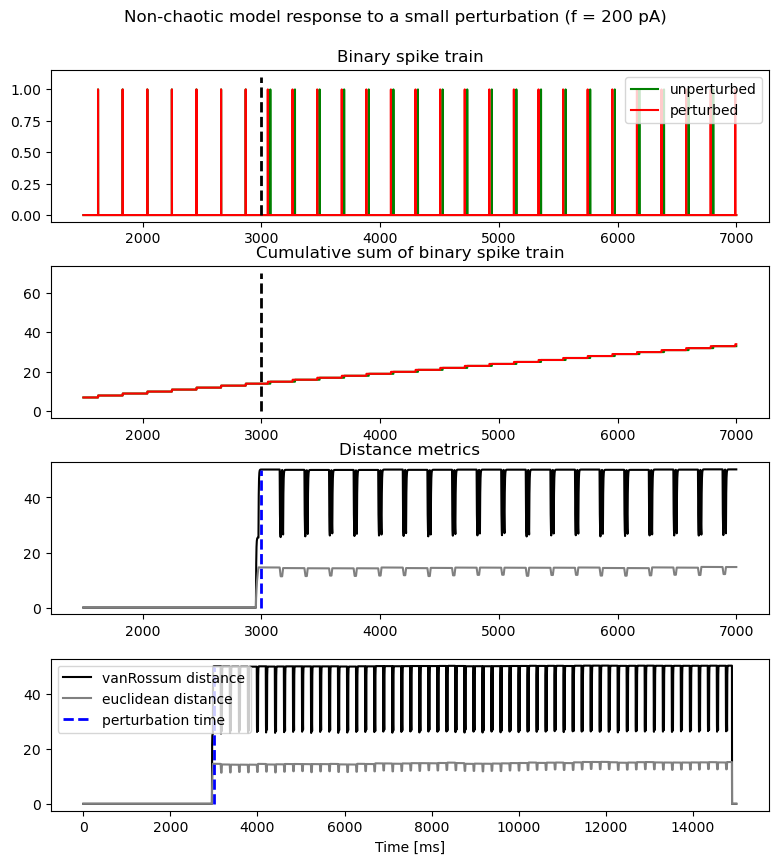

In [12]:
## Calculate the rolling van Rossum distance between the corresponding spike trains
# with and without a perturbation..
tau = 5     # ms
T_filter = 7 * tau
filter_length = int(T_filter/dt)
filter = np.exp(-np.linspace(0, T_filter, filter_length)/tau)

window = 2000

# binarise the spike trains...

bin_spikes = binarise_spikes(spikes, dt, N_iter)
cusum = np.cumsum(bin_spikes, axis = 1)

# Rolling van Rossum distance
VR_200 = rolling_VR_dist(bin_spikes[0, :], bin_spikes[1, :], filter, window)
VR_250 = rolling_VR_dist(bin_spikes[2, :], bin_spikes[3, :], filter, window)

# Rolling euclidean distance between cusum
euclid_200 = rolling_euclid_distance(cusum[0, :], cusum[1, :], window)
euclid_250 = rolling_euclid_distance(cusum[2, :], cusum[3, :], window)

fig, ax = plt.subplots(4, 1, figsize = (8, 8))
fig.tight_layout()
#split = np.arange(8000, 30000, 1)

print(perturb_idx)

ax[0].set_title('Binary spike train')
ax[0].plot(t[split], bin_spikes[0, split], c = 'green', label = 'unperturbed')
ax[0].plot(t[split], bin_spikes[1, split], c = 'red', label = 'perturbed')
ax[0].vlines(perturb_time, ymin = 0, ymax = 1.1, color = 'black', linewidth = 2, linestyle = '--')
ax[0].legend(loc = 'upper right')

conv_0 = np.convolve(bin_spikes[0, :], filter)
conv_1 = np.convolve(bin_spikes[1, :], filter)
ax[1].set_title('Cumulative sum of binary spike train')
ax[1].plot(t[split], cusum[0, split], c = 'green', label = 'unperturbed')
ax[1].plot(t[split], cusum[1, split], c = 'red', label = 'perturbed')
ax[1].vlines(perturb_time, ymin = 0, ymax = 70, color = 'black', linewidth = 2, linestyle = '--')

ax[2].set_title('Distance metrics')
ax[2].plot(t[split], VR_200[split], c = 'black', label = 'rolling VR distance')
ax[2].plot(t[split], euclid_200[split], c = 'grey', label = 'rolling euclid distance')
ax[2].vlines(perturb_time, ymin = 0, ymax = 50, color = 'blue', linewidth = 2, linestyle = '--')

ax[3].plot(t, VR_200, c = 'black', label = 'vanRossum distance')
ax[3].plot(t, euclid_200, c = 'grey', label = 'euclidean distance')
ax[3].vlines(perturb_time, ymin = 0, ymax = 50, color = 'blue', linewidth = 2, linestyle = '--', label = 'perturbation time')
ax[3].set_xlabel('Time [ms]')
ax[3].legend()

fig.suptitle('Non-chaotic model response to a small perturbation (f = 200 pA)', y = 1.05)

plt.savefig('RS_chaos//RS_nonchaotic_distances.png')


30000


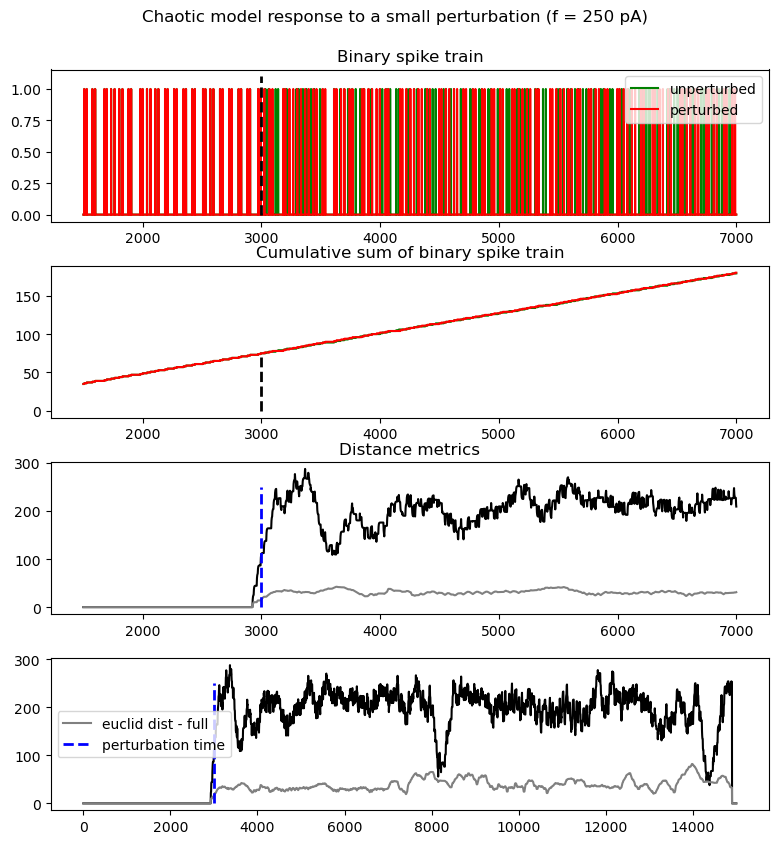

In [13]:
fig, ax = plt.subplots(4, 1, figsize = (8, 8))
fig.tight_layout()
#split = np.arange(8000, 30000, 1)

print(perturb_idx)

ax[0].set_title('Binary spike train')
ax[0].plot(t[split], bin_spikes[2, split], c = 'green', label = 'unperturbed')
ax[0].plot(t[split], bin_spikes[3, split], c = 'red', label = 'perturbed')
ax[0].vlines(perturb_time, ymin = 0, ymax = 1.1, color = 'black', linewidth = 2, linestyle = '--')
ax[0].legend(loc = 'upper right')

conv_2 = np.convolve(bin_spikes[2, :], filter)
conv_3 = np.convolve(bin_spikes[3, :], filter)
ax[1].set_title('Cumulative sum of binary spike train')
ax[1].plot(t[split], cusum[2, split], c = 'green', label = 'unperturbed')
ax[1].plot(t[split], cusum[3, split], c = 'red', label = 'perturbed')
ax[1].vlines(perturb_time, ymin = 0, ymax = 70, color = 'black', linewidth = 2, linestyle = '--')

ax[2].set_title('Distance metrics')
ax[2].plot(t[split], VR_250[split], c = 'black', label = 'unperturbed')
ax[2].plot(t[split], euclid_250[split], c = 'grey', label = 'rolling euclid_dist - slice')
ax[2].vlines(perturb_time, ymin = 0, ymax = 250, color = 'blue', linewidth = 2, linestyle = '--')

ax[3].plot(t, VR_250, c = 'black')
ax[3].plot(t, euclid_250, c = 'grey', label = 'euclid dist - full')
ax[3].vlines(perturb_time, ymin = 0, ymax = 250, color = 'blue', linewidth = 2, linestyle = '--', label = 'perturbation time')
ax[3].legend()

fig.suptitle('Chaotic model response to a small perturbation (f = 250 pA)', y = 1.05)

plt.savefig('RS_chaos//RS_chaotic_distances.png')

In [14]:
'''
### Test the recurrence plot functionality and RQA functions
from pyrqa.time_series import TimeSeries
from pyrqa.settings import Settings
from pyrqa.analysis_type import Classic
from pyrqa.neighbourhood import FixedRadius
from pyrqa.metric import EuclideanMetric
from pyrqa.computation import RQAComputation
from pyrqa.computation import RPComputation
from pyrqa.image_generator import ImageGenerator


data_points = bin_spikes[0, :]
time_series = TimeSeries(data_points,
                         embedding_dimension=2,
                         time_delay=2)
settings = Settings(time_series,
                    analysis_type=Classic,
                    neighbourhood=FixedRadius(0.65),
                    similarity_measure=EuclideanMetric,
                    theiler_corrector=1)
computation = RQAComputation.create(settings,
                                    verbose=True)
result = computation.run()
result.min_diagonal_line_length = 2
result.min_vertical_line_length = 2
result.min_white_vertical_line_length = 2
print(result)

# create the recurrence plot
computation = RPComputation.create(settings)
result = computation.run()
ImageGenerator.save_recurrence_plot(result.recurrence_matrix_reverse,
                                    'recurrence_plot.png')
'''

"\n### Test the recurrence plot functionality and RQA functions\nfrom pyrqa.time_series import TimeSeries\nfrom pyrqa.settings import Settings\nfrom pyrqa.analysis_type import Classic\nfrom pyrqa.neighbourhood import FixedRadius\nfrom pyrqa.metric import EuclideanMetric\nfrom pyrqa.computation import RQAComputation\nfrom pyrqa.computation import RPComputation\nfrom pyrqa.image_generator import ImageGenerator\n\n\ndata_points = bin_spikes[0, :]\ntime_series = TimeSeries(data_points,\n                         embedding_dimension=2,\n                         time_delay=2)\nsettings = Settings(time_series,\n                    analysis_type=Classic,\n                    neighbourhood=FixedRadius(0.65),\n                    similarity_measure=EuclideanMetric,\n                    theiler_corrector=1)\ncomputation = RQAComputation.create(settings,\n                                    verbose=True)\nresult = computation.run()\nresult.min_diagonal_line_length = 2\nresult.min_vertical_line_leng